In [79]:
import pandas as pd 


In [80]:
df=pd.DataFrame({
    "EngineSize":[1,1.5,2.0,2.5,3.0],
    "Co2":[100,120,140,160,180]
})
df

,EngineSize,Co2
0,1.0,100
1,1.5,120
2,2.0,140
3,2.5,160
4,3.0,180


X= input ie the engine size 
Y= output ie the co2 emmitted by the car 

y=mx+c

In [81]:
m=10
c=50

x=1.0
prediction=m*x+c
prediction

60.0

In [82]:
# see model predicted 60 and actual is 100 
# so the error will be 

#100-60=40

## out goal is to derive the formula for the gradient descent (GD) aka J
#### yp=y predicted values 
#### ya= y actual values
#### m=slope of line 
#### c= intercept on y axis 


### X           ya        yp    error 
### 1           100       0      100
### 2           140       0      140

m=0
c=0

yp=mx+c 
for x=1 > yp=0*1+0 = 0
for x=2 > yp=0*2+0=0


GD=1/n*(ya-yp)^2  => cost function 

GD=1/n*(ya-mx+c)^2  ### we need to minimize this gd value of cost function value 

### we will do the partial derivative of gd wrt m 

#### GD=-2/n{x*(ya-(mx+c))
#### gd= -2/n{x*(ya-yp)

#### gd=-2/n*(np.sum(x*(y-y_ypred)))


In [83]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [84]:
data=pd.read_csv("fueldata.csv")
data.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [85]:
data=data.rename(columns={"Engine Size(L)":"EngSize","CO2 Emissions(g/km)":"Co2Em"})
data.describe()

,EngSize,Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Co2Em
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


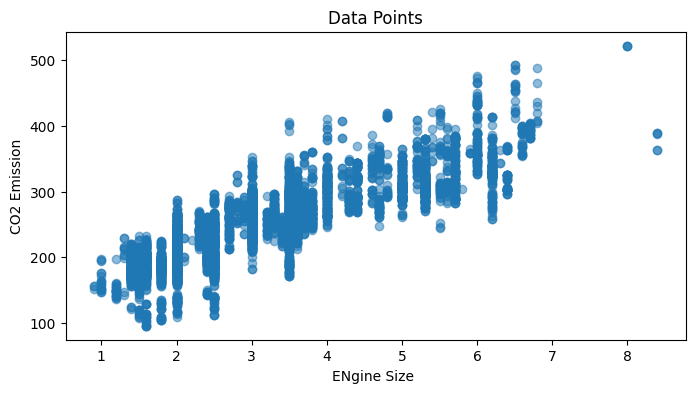

In [86]:
x=data["EngSize"]
y=data["Co2Em"]

plt.figure(figsize=(8,4))

plt.scatter(x,y,alpha=0.5)
plt.xlabel("ENgine Size ")
plt.ylabel("CO2 Emission")
plt.title("Data Points")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

X=data[["EngSize"]]
Y=data["Co2Em"]


model=LinearRegression()

model.fit(X,Y)



array([36.77731519])

In [88]:
print("this is the slope of the best fit line ",model.coef_)
print("This is the value of C or intercept ",model.intercept_)


this is the slope of the best fit line  [36.77731519]
This is the value of C or intercept  134.3658927234963


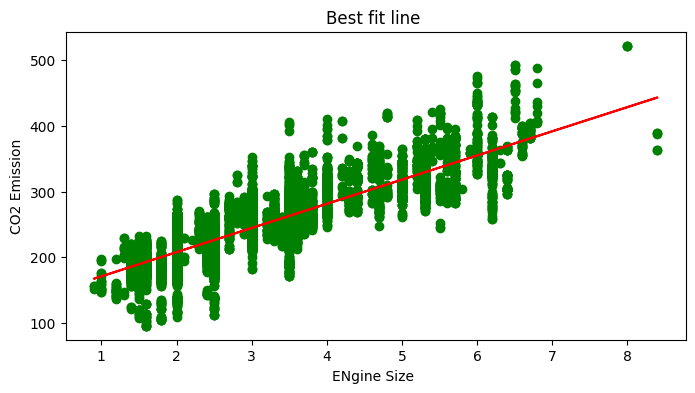

In [102]:
y_pred=model.predict(X)


plt.figure(figsize=(8,4))
plt.scatter(X,Y,color="green") # this is creating the scatter plot graph 

plt.plot(X,y_pred,color="red")  # this is plotting a straight line through the data point 


plt.xlabel("ENgine Size ")
plt.ylabel("CO2 Emission")
plt.title("Best fit line ")
plt.show()

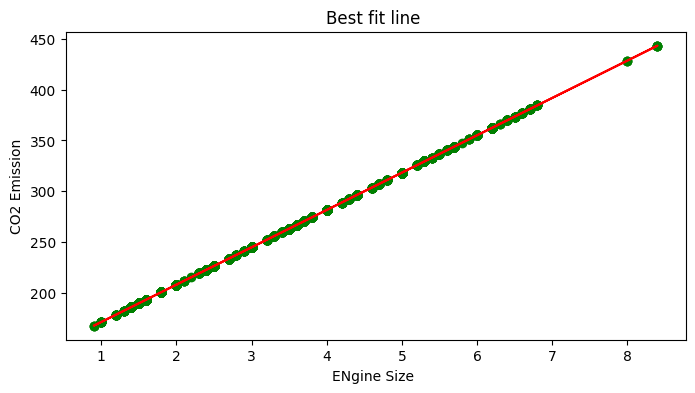

In [103]:
y_pred=model.predict(X)


plt.figure(figsize=(8,4))
plt.scatter(X,y_pred,color="green") # this is creating the scatter plot graph 

plt.plot(X,y_pred,color="red")  # this is plotting a straight line through the data point 


plt.xlabel("ENgine Size ")
plt.ylabel("CO2 Emission")
plt.title("Best fit line ")
plt.show()

In [104]:
new_eng=[[2.4]]
pred_val=model.predict(new_eng)
pred_val

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([222.63144917])

In [105]:
# error= Y_actual- Y_predicted  ie MAE

error=Y-y_pred
error.head()


0   -11.920523
1    -1.631449
2   -53.531866
3    -8.086496
4   -19.086496
Name: Co2Em, dtype: float64

In [106]:
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(Y,y_pred)
mse # mean square error and they are also called cost functions

rmse=np.sqrt(mse)
rmse # root mean square error  and they are also called cost functions 

30.713053083423187

In [128]:
gdm=(-2/len(X))*np.sum(X.values.flatten()*(Y.values-y_pred))
print("gradient descent of m",gdm)
gdc=(-2/len(X))*np.sum((Y.values-y_pred))

print("Gradient Descent of C is ",gdc)

gradient descent of m -1.210853338907438e-12
Gradient Descent of C is  7.438521325265384e-14


In [123]:
#m_new=m_old-(lr*gdm)  slope update formula 
# C_new = C_old-(lr*gdc) intercept update formula 


#### Practical Approach 

In [ ]:
df=pd.read_csv("fueldata.csv")
df=df.rename(columns={"Engine Size(L)":"ES","CO2 Emissions(g/km)":"CO2"})


,Make,Model,Vehicle Class,ES,Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232


In [ ]:
X_val=df["ES"].values
Y_val=df["CO2"].values

m=0 # slope 
c=0 # intercept 

lr=0.01 ## learning rate of the model how frequenty it will learn from the data 
epochs=1000# how many times my model will learn from the data 

In [ ]:
n=len(X_val)
costhitory=[]
for epoch in range(epochs):
    y_predict=m*X_val+c
    cost=1/n*np.sum(Y_val-y_predict)**2
    gdm=-2/n*np.sum(X_val*(Y_val-y_predict)) ## imp 
    gdc=-2/n*np.sum((Y_val-y_predict)) ### very imp 
    m=m-(lr*gdm)
    c=c-(lr*gdc)
    costhitory.append(cost)

   

print("Slope ",m)
print("Intercept ",c)
print("GDM",gdm)
print("GDC",gdc)
print(costhitory[-1])

Slope  36.7776058350331
Intercept  134.36481891954514
GDM 8.43334587662277e-05
GDC -0.000311570730637716
0.0001792271561510094
